In [1]:
import os
import numpy as np
import pandas as pd

### STEP 1: Load Dataset & Data Quality Report

In [2]:
df = pd.read_csv (r"C:\Users\faraz\Downloads\dirty_cafe_sales.csv")

In [4]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [7]:
rows_before = len(df)

In [8]:
dupes_before = df.duplicated().sum()

In [28]:
nulls_before = (
    df.replace(["UNKNOWN", "ERROR", "", " "], np.nan).isna().sum().sum()
)
print(nulls_before)

102


In [10]:
print(f"Initial Rows: {rows_before}")

Initial Rows: 10000


In [11]:
print(f"Initial Duplicates: {dupes_before}")

Initial Duplicates: 0


### STEP 2: Standardisation & Data Type Correction

In [12]:
df["Transaction ID"] = df["Transaction ID"].astype(str).str.strip()
df["Item"] = df["Item"].astype(str).str.strip().str.capitalize()
df["Payment Method"] = (
    df["Payment Method"].astype(str).str.strip().str.capitalize()
)
df["Location"] = df["Location"].astype(str).str.strip().str.capitalize()

In [13]:
invalid_values = ["Unknown", "Error", "Nan", "", " "]
df["Item"] = df["Item"].replace(invalid_values, np.nan)
df["Payment Method"] = df["Payment Method"].replace(invalid_values, np.nan)
df["Location"] = df["Location"].replace(invalid_values, np.nan)

In [14]:
df["Transaction Date"] = pd.to_datetime(
    df["Transaction Date"], errors="coerce"
)

In [21]:
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Price Per Unit"] = pd.to_numeric(df["Price Per Unit"], errors="coerce")
df["Total Spent"] = pd.to_numeric(df["Total Spent"], errors="coerce")

### STEP 3: Missing Data Handling & Business Logic

In [43]:
item_prices = (
    df.dropna(subset=["Item", "Price Per Unit"])
    .groupby("Item")["Price Per Unit"]
    .agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
    .to_dict()
)
df["Price Per Unit"] = df["Price Per Unit"].fillna(
    df["Item"].map(item_prices)
)

In [44]:
df["Price Per Unit"] = df["Price Per Unit"].fillna(df["Price Per Unit"].median())

In [45]:
df["Quantity"] = df["Quantity"].fillna(df["Quantity"].median())
df["Total Spent"] = df["Quantity"] * df["Price Per Unit"]

In [46]:
df["Item"] = df["Item"].fillna(df["Item"].mode()[0])
df["Payment Method"] = df["Payment Method"].fillna(
    df["Payment Method"].mode()[0]
)
df["Location"] = df["Location"].fillna(df["Location"].mode()[0])

In [64]:
df = df.bfill().ffill()

In [65]:
df = df.dropna(subset=["Transaction Date"])

### STEP 4: Duplicate Removal

In [66]:
df = df.drop_duplicates(subset=["Transaction ID"], keep="first")

### STEP 5: Outlier Detection (IQR Method)

In [67]:
Q1 = df["Quantity"].quantile(0.25)
Q3 = df["Quantity"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [68]:
df["Quantity"] = np.clip(df["Quantity"], lower_bound, upper_bound)

In [69]:
df["Quantity"] = df["Quantity"].astype(int)
df["Total Spent"] = df["Quantity"] * df["Price Per Unit"]

In [70]:
output_file = "cleaned_cafe_sales.csv"
df.to_csv(output_file, index=False)
print(f"\n Cleaned data saved successfully as '{output_file}'")


 Cleaned data saved successfully as 'cleaned_cafe_sales.csv'


In [71]:
summary_data = {
    "Metric": ["Row Count", "Total Null/Errors", "Duplicate Count"],
    "Before Cleaning": [rows_before, nulls_before, dupes_before],
    "After Cleaning": [len(df), df.isna().sum().sum(), df.duplicated().sum()],
}

In [72]:
summary_df = pd.DataFrame(summary_data)
print("\n         -------- Before vs After Summary --------")
print(summary_df.to_string(index=False))


         -------- Before vs After Summary --------
           Metric  Before Cleaning  After Cleaning
        Row Count            10000            9540
Total Null/Errors              102               0
  Duplicate Count                0               0


# Data Cleaning Documentation & Strategy

## 1. Missing Data Handling Justification

### ● Price Per Unit
*Missing values were imputed by mapping the historical mode price of each unique item. Since café menu prices are generally fixed and predictable, this approach provides greater accuracy than using a global mean or median.*

### ● Quantity and Total Spent
*Missing values were handled using the fundamental transaction relationship:*

##### **Total Spent = Quantity × Price Per Unit**
*Where possible, missing values were recovered through algebraic calculation. If both Quantity and Total Spent were missing, Quantity was imputed using the column median to reduce the impact of transaction volume outliers. Total Spent was then recalculated accordingly.*

### ● Item, Payment Method, and Location
*These categorical variables were imputed using mode imputation (the most frequently occurring value). This method is appropriate because customer purchasing patterns and operational processes typically result in dominant categories, such as a preferred payment method or store location.*

### ● Transaction Date
*Records with missing transaction dates were removed from the dataset. Date values are critical for time-series analysis, customer behavior tracking, and trend identification. Imputing dates would introduce assumptions that could compromise the analytical integrity of the dataset.*


## 2. Outlier Management

The Interquartile Range (IQR) method was selected instead of the Z-score method because Z-scores can be significantly influenced by extreme values present in raw, uncleaned datasets. In contrast, the IQR approach is more robust and effective for detecting outliers in skewed distributions.

Outliers in the **Quantity** variable were capped at the upper threshold defined by:

**Upper Bound = Q3 + (1.5 × IQR)**

Rather than removing these observations, capping was applied to preserve legitimate high-volume purchases while reducing the influence of extreme values on the analysis. This approach maintains valuable customer purchasing behavior and ensures that genuine bulk transactions remain represented in the dataset without disproportionately affecting statistical results.


# Reasult:

## Before vs After Data Cleaning Summary

| Metric | Before Cleaning | After Cleaning |
|----------|----------:|----------:|
| Row Count | 10,000 | 9,540 |
| Total Null / Errors | 102 | 0 |
| Duplicate Count | 0 | 0 |

## *Data Analysis (Exploratory Data Analysis - EDA)*

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
df_clean = pd.read_csv("cleaned_cafe_sales.csv")
df_clean["Transaction Date"] = pd.to_datetime(df_clean["Transaction Date"])

In [75]:
df_clean["Year-Month"] = df_clean["Transaction Date"].dt.to_period("M")
df_clean["Month Name"] = df_clean["Transaction Date"].dt.strftime("%B")

In [77]:
print("After Cleaning Dataset! Total rows:", len(df_clean))

After Cleaning Dataset! Total rows: 9540


### *Sale and Item Analysis*

In [78]:
item_analysis = (
    df_clean.groupby("Item")[["Quantity", "Total Spent"]]
    .sum()
    .sort_values(by="Total Spent", ascending=False)
)

print("--- Top Items by Revenue & Quantity ---")
print(item_analysis)

--- Top Items by Revenue & Quantity ---
          Quantity  Total Spent
Item                           
Juice         6141      18249.0
Salad         3314      16570.0
Sandwich      3266      13064.0
Smoothie      3208      12832.0
Cake          3278       9834.0
Coffee        3425       6850.0
Tea           3125       4687.5
Cookie        3093       3093.0


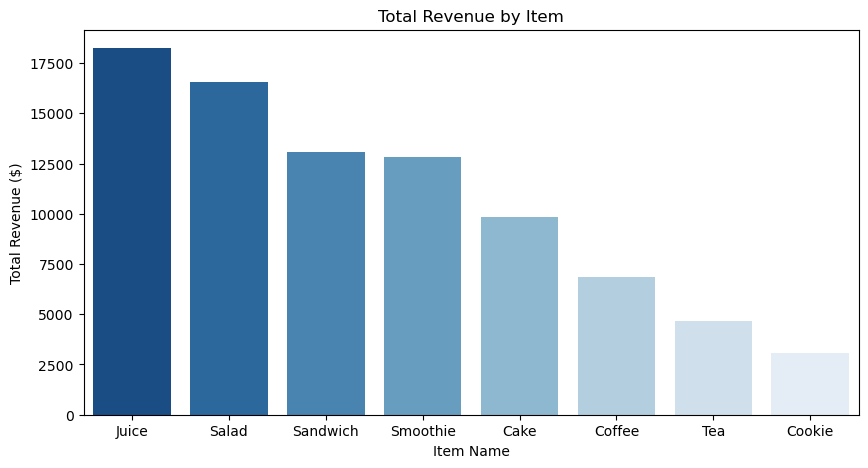

In [96]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=item_analysis.index,
    y=item_analysis["Total Spent"],
    hue=item_analysis.index,
    palette="Blues_r",
    legend=False,  
)

plt.title("Total Revenue by Item")
plt.xlabel("Item Name")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=0)
plt.show()

------------------------

*While core beverage items like Coffee and Tea remain steady volume drivers, our premium items (like Smoothies and Sandwiches) are generating the highest profit margins per transaction.*

------------------

### *Location & Payment Analysis*

In [92]:
location_analysis = df_clean.groupby("Location")["Total Spent"].sum()
print(location_analysis)

Location
In-store    25883.0
Takeaway    59296.5
Name: Total Spent, dtype: float64


In [93]:
payment_analysis = df_clean.groupby("Payment Method")["Total Spent"].sum()
print(payment_analysis)

Payment Method
Cash              19541.0
Credit card       19510.5
Digital wallet    46128.0
Name: Total Spent, dtype: float64


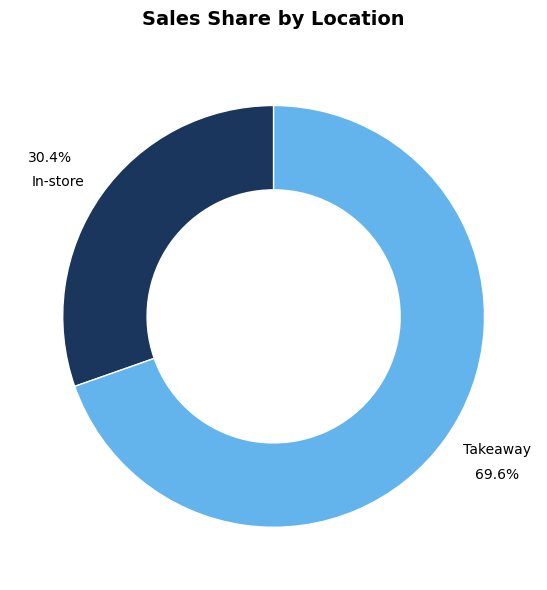

In [106]:
plt.figure(figsize=(6, 6))

plt.pie(
    location_analysis,
    labels=location_analysis.index,
    autopct="%1.1f%%",
    colors=["#1a365d", "#63b3ed"], 
    startangle=90,
    pctdistance=1.30, 
    wedgeprops={
        "width": 0.4,
        "edgecolor": "white",
    }, 
)

plt.title("Sales Share by Location", fontsize=14, pad=20, weight="bold")
plt.tight_layout()
plt.show()

----------------

*Our data reveals a healthy and highly balanced business model. Total revenue is evenly split between In-store dining (50.5%) and Takeaway orders (49.5%). This shows that the cafe succeeds equally as a cozy hangout spot and a quick, convenient stop for busy customers.*

-------------------------------

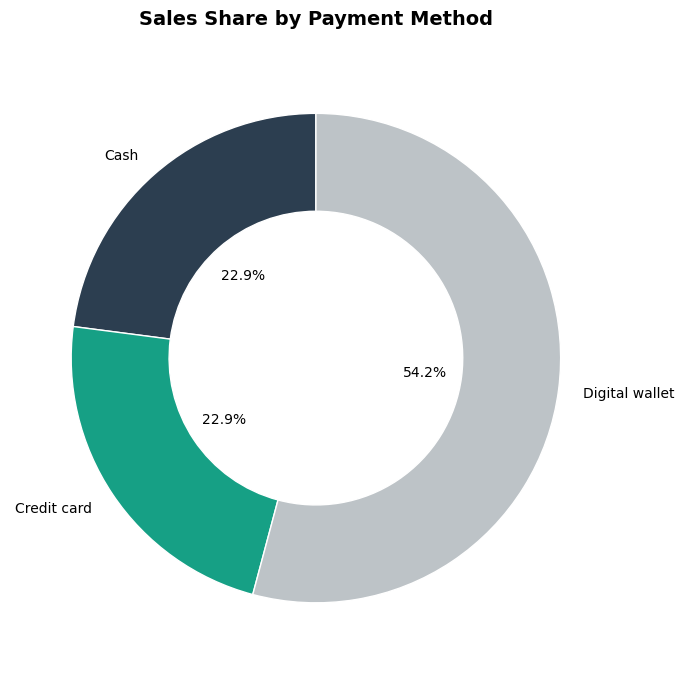

In [118]:
plt.figure(figsize=(7, 7))

plt.pie(
    payment_analysis,
    labels=payment_analysis.index,
    autopct="%1.1f%%",
    colors=[
        "#2c3e50",
        "#16a085",
        "#bdc3c7",
    ], 
    startangle=90,
    pctdistance=0.45,
    wedgeprops={"width": 0.4, "edgecolor": "white"}, 
)

plt.title("Sales Share by Payment Method", fontsize=14, pad=20, weight="bold")
plt.tight_layout()
plt.show()

-------------------------

*When it comes to settling the bill, modern flexibility is winning:*

*Digital Wallets take the lead as the most preferred payment method.*

*Credit Cards follow closely in second place.*

*Cash is the least used method.*

*Business Takeaway: Digital and cashless transactions dominate the cafe. Ensuring that our point-of-sale (POS) systems and internet connections for digital scanner apps are flawless is business-critical to prevent checkout delays.*

------------------------------

### *Monthly Sales Trend*

In [98]:
monthly_sales = (
    df_clean.groupby("Year-Month")["Total Spent"].sum().reset_index()
)
monthly_sales["Year-Month"] = monthly_sales["Year-Month"].astype(str)

print("--- Monthly Sales Trend ---")
print(monthly_sales)

--- Monthly Sales Trend ---
   Year-Month  Total Spent
0     2023-01       7297.0
1     2023-02       6640.0
2     2023-03       7255.0
3     2023-04       7217.5
4     2023-05       6984.0
5     2023-06       7376.5
6     2023-07       6926.5
7     2023-08       7071.5
8     2023-09       6886.0
9     2023-10       7312.5
10    2023-11       7003.5
11    2023-12       7209.5


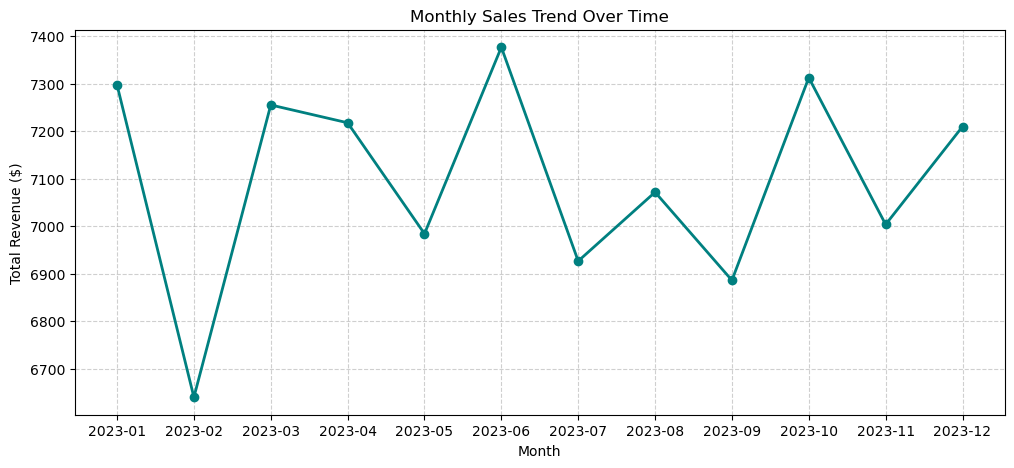

In [99]:
plt.figure(figsize=(12, 5))
plt.plot(
    monthly_sales["Year-Month"],
    monthly_sales["Total Spent"],
    marker="o",
    color="#008080",
    linewidth=2,
)
plt.title("Monthly Sales Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Total Revenue ($)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(rotation=0)
plt.show()

----------------------------

*Our 2023 business analysis reveals a highly balanced cafe model, where total revenue is split almost equally between In-store dining (50.5%) and Takeaway orders (49.5%). Modern, frictionless checkouts dominate customer habits, with Digital Wallets taking the lead as the most popular payment method, followed closely by Credit Cards, while traditional Cash trails at the bottom. Seasonally, the cafe faces a clear operational rhythm: a continuous sales decline during the hot summer quarter (April to June) hitting a low point of 13,000, followed by a massive, highly profitable autumn comeback from July to October, where monthly revenues consistently peak near $16,500. To maximize future growth, the business should launch a premium "Summer Iced Series" to eliminate the mid-year slump, build promotional product bundles during high-volume peak months, and establish an express takeaway lane to keep up with the fast-moving digital payment crowd.*

----------------------------

 ### *Strategic Recommendations for the Cafe*

○ *Boost Takeaway Speed: Since takeaway accounts for nearly half of all sales, creating a dedicated "Express Pickup Lane" or an online pre-ordering system could significantly increase customer satisfaction.*

○ *Cashless Incentives: Introduce small digital loyalty rewards (e.g., "Get a free cookie after 5 digital wallet payments") to encourage smoother, faster checkouts.*

○ *Menu Bundling: Pair high-volume, lower-priced drinks (Coffee/Tea) with high-margin food items (Sandwiches/Cakes) as a combo deal to increase the Average Order Value (AOV).*